# Open Loop Analysis
This notebook performs step tests on the placeholder well simulator to generate open-loop response data, plots steady-state gain curves, and fits simple FOPDT/First-order models for the predictive controller.

In [1]:
import sys
import os
sys.path.append(os.path.abspath('../src'))
import model_id
import pandas as pd
import matplotlib.pyplot as plt

## 1. Run Step Tests
Stepping the choke from 0 to 100% in 10% increments, allowing 15 hours per step to reach steady state.

In [2]:
# Run tests and save to data directory
df = model_id.run_step_tests(output_data_path='../data/step_test_data.csv')
df.head()

Step test data saved to ../data/step_test_data.csv


,Time_hr,Choke_pct,Q_bbl_hr,WHP_psi,FLP_psi,BHP_psi
0,0,0,0.0,3000.0,200.0,3000.0
1,1,0,0.0,3000.0,200.0,3000.0
2,2,0,0.0,3000.0,200.0,3000.0
3,3,0,0.0,3000.0,200.0,3000.0
4,4,0,0.0,3000.0,200.0,3000.0


## 2. Plot Gain Curves
Plot the steady-state value of Q, WHP, FLP, and BHP against the choke opening.

Gain curves plot saved to ../plots\gain_curves.png


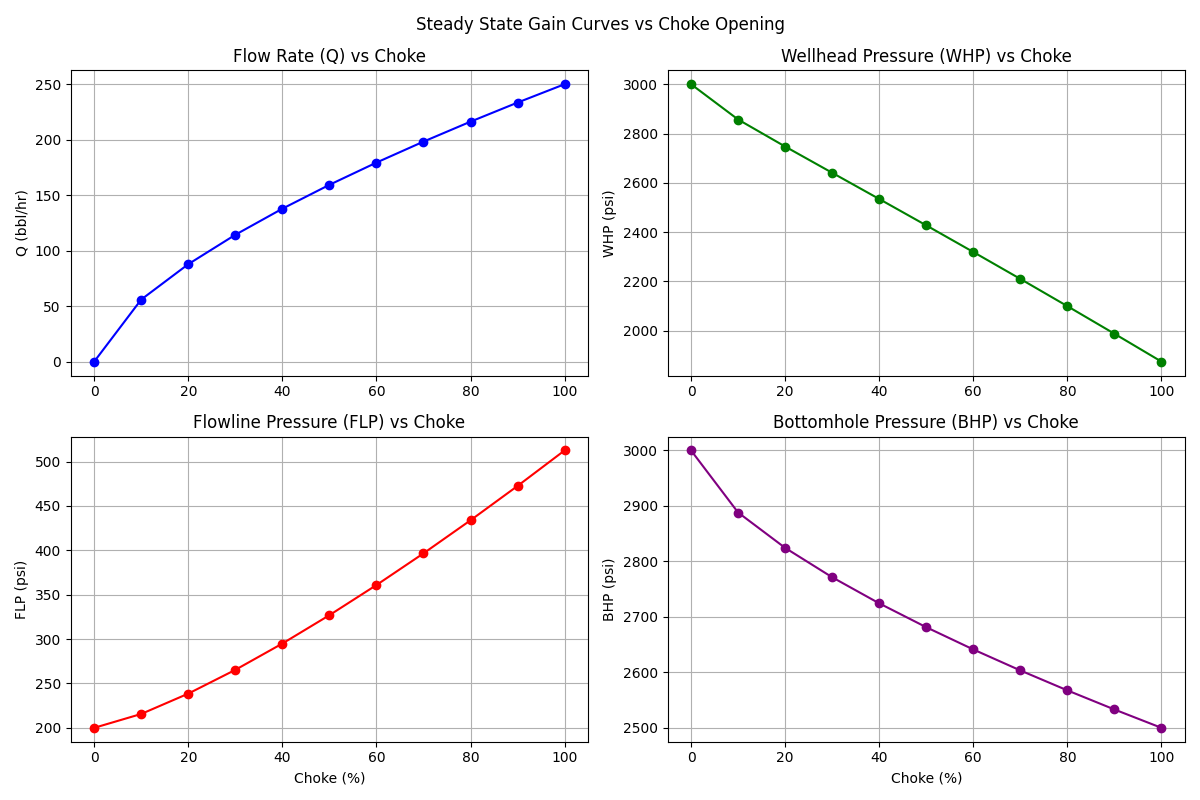

In [3]:
model_id.plot_gain_curves(df, output_plot_dir='../plots')

# Display the saved plot in the notebook
from IPython.display import Image, display
display(Image(filename='../plots/gain_curves.png'))

## 3. Fit First-Order Models
Fit a simple first-order model for a step change around the operating point (e.g., 50% to 60%). This will provide the gains ($K$) and time constants ($\tau$) for the predictive controller.

In [4]:
models = model_id.fit_first_order_models(df)


--- FITTED FOPDT/FIRST ORDER PARAMETERS (50% -> 60% Step) ---
Q_bbl_hr   : K =    2.006, tau = 2.00 hr
WHP_psi    : K =  -10.813, tau = 2.05 hr
FLP_psi    : K =    3.401, tau = 2.07 hr
BHP_psi    : K =   -4.011, tau = 2.00 hr
